Helper functions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
import pandas as pd
import torch
from scipy.integrate import solve_ivp
from collections.abc import Callable
from typing import Tuple

# Helper: wrap a PyTorch model that takes a torch tensor of shape (N,) or (N,1)
def make_torch_wrapper(pt_model, device="cpu", batch_dim=False):
    """
    Wrap a PyTorch model so it can be called as a numpy function u -> out (numpy array).
    - pt_model should accept a torch tensor of shape (N,) or (N,1) and return (N,) or (N,1)
    - device: 'cpu' or 'cuda'
    - batch_dim: if True, the model expects input shape (batch, N) or similar; keep False for elementwise
    Returns: callable(u_numpy) -> numpy array
    """
    pt_model.to(device)
    pt_model.eval()
    def wrapper(u_np: np.ndarray) -> np.ndarray:
        # Convert to torch tensor
        with torch.no_grad():
            u_t = torch.from_numpy(u_np.astype(np.float32)).to(device)
            # If model expects shape (N,1), reshape
            if u_t.ndim == 1:
                u_t_in = u_t.unsqueeze(1)  # (N,1)
            else:
                u_t_in = u_t
            out = pt_model(u_t_in)
            # If out has shape (N,1) or (N,), convert to 1D numpy
            out_np = out.detach().cpu().numpy()
            out_np = out_np.reshape(u_np.shape)
        return out_np
    return wrapper


# --- Analytic FKPP traveling wave (Ablowitz–Zeppetella) ---
def u_fkpp_az(x, t, D, r, x0=0.0, c=None):
    """
    Analytic AZ solution of u_t = D u_xx + r u (1 - u)
    u(x,t) = 1 / (1 + exp( (x - x0 - c t) * sqrt(r/(6D)) ))^2
    valid only for c = (5/sqrt(6)) * sqrt(D r).
    """
    if c is None:
        c = (5.0/np.sqrt(6.0)) * np.sqrt(D*r)
    z = (x - x0 - c*t) * np.sqrt(r/(6.0*D))
    return 1.0 / (1.0 + np.exp(z))**2, c

# reconstruct the solution using the learned NN 'D_model' and 'f_model' at the training points (x_train, t_train)
def recon_plot(x_train, t_train, D_model, f_model, u_NN_IC):
    D_callable = make_torch_wrapper(D_model, device='cpu')
    f_callable = make_torch_wrapper(f_model, device='cpu')
    u_sim = simulate_pde(x_train, u_NN_IC, D_callable, f_callable,
                       t_span=(t_train[0], t_train[-1]),
                       t_eval=t_train,
                       integrator="RK45")
    return u_sim

# Simulate the FKPP with Neumann BCs using method of lines and solve_ivp
def simulate_pde(x: np.ndarray,
                 IC: np.ndarray,
                 D_callable: Callable[[np.ndarray], np.ndarray],
                 f_callable: Callable[[np.ndarray], np.ndarray],
                 t_span: Tuple[float, float] = (0.0, 20.0),
                 t_eval: np.ndarray = None,
                 integrator: str = "RK45",
                 rtol: float = 1e-6,
                 atol: float = 1e-8,
                 save_path: str = None):
    """
    Simulate u_t = (D(u) u_x)_x + u * f(u)
    Inputs:
      x           : 1D grid (numpy array)
      IC          : initial condition (numpy array same length as x)
      D_callable  : function(u_array) -> D_array (same length as u)
      f_callable  : function(u_array) -> f_array (same length as u); PDE uses u * f(u)
      t_span      : (t0, tf)
      t_eval      : times to evaluate solution; default 201 points between t0 and tf
      integrator  : "RK45" or "BDF" etc; BDF recommended if stiff
      rtol, atol  : tolerances for solve_ivp
      save_path   : optional path to save final u as npy
    Returns:
      sol : the SciPy OdeResult-like object from solve_ivp (sol.y shape (N, len(t_eval)))
    """
    
    x = np.asarray(x)
    N = x.size
    dx = x[1] - x[0]
    assert IC.shape == x.shape, "IC must match x shape"
    if t_eval is None:
        t_eval = np.linspace(t_span[0], t_span[1], 201)

    def rhs(t, u_vec):
        u = np.asarray(u_vec)

        Dn = D_callable(u)
        if Dn.shape != u.shape:
            raise ValueError("D_callable must return array of same shape as u")

        u_ext = np.empty(N + 2, dtype=u.dtype)
        u_ext[1:-1] = u
        u_ext[0] = u[1]
        u_ext[-1] = u[-2]

        D_ext = np.empty(N + 2, dtype=Dn.dtype)
        D_ext[1:-1] = Dn
        D_ext[0] = Dn[1]
        D_ext[-1] = Dn[-2]

        D_half = 0.5 * (D_ext[:-1] + D_ext[1:])
        flux = D_half * (u_ext[1:] - u_ext[:-1]) / dx
        diffusion_term = (flux[1:] - flux[:-1]) / dx

        fu = f_callable(u)
        if fu.shape != u.shape:
            raise ValueError("f_callable must return array same shape as u")
        reaction_term = u * fu

        return diffusion_term + reaction_term
    
    sol = solve_ivp(rhs, t_span, IC, method=integrator, t_eval=t_eval, rtol=rtol, atol=atol)

    if not sol.success:
        print("Warning: solver reported failure:", sol.message)
    if save_path is not None:
        np.save(save_path, sol.y[:, -1])
        print(f"Saved final state to {save_path}")
        
    return sol.y.T



Plot formatting & setups 

In [2]:
# plot formatting
plt.rcParams['font.family'] = 'overall_overall_times New Roman'
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.labelweight'] = 'bold'  # Bold axis labels
plt.rcParams['axes.titleweight'] = 'bold'  # Bold title
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['font.size'] = str(20)
plt.rcParams['lines.linewidth'] = 2
alpha_val = 0.4

# epochs for training history
epoch_hist = np.arange(0, 4001, 1)

# time resolution
Nt, t_end, t_min = 7, 4.5, 0.0
t_train = np.linspace(t_min, t_end, Nt)

# spatial resolutions
L = 7.0
x_min, x_max = -L, L
dx_long = 0.04
x_train_long = np.arange(x_min, x_max+dx_long, dx_long)
# subsampled the spatial grid for training the BINN
x_train = x_train_long[::5]
dx = x_train[1] - x_train[0]
Nx = len(x_train)

# fine solution for training data generation
xx, tt = np.meshgrid(x_train_long, t_train)
D, r_true = 0.1, 1.0
#D, r_true = 0.2, 1.0 #####################################
ell = np.sqrt(6.0 * D / r_true)
x0 = 0.0
u_true_long, c = u_fkpp_az(xx, tt, D, r_true, x0=x0)
# subsampled true solution at training points
u_true = u_true_long[:, ::5]
u_min_np, u_max_np = u_true.min(), u_true.max()
U_grid= np.linspace(u_min_np, u_max_np, Nx)

G_true = r_true * (1 - U_grid)
D_true = D * np.ones_like(U_grid)


# the variances we used 
variances = [0.0, 0.01, 0.001]
#variances = [0.001] #####################################
seed = 2

NumRep = 10

top_load_folder = '../ARCresults_subsampled/'
top_save_folder = '../Figures_subsampled/Fig3_subsampled/'

FKPP_subfolders = ['Fisher_KPP_addnoise_var0.0_subsample/', 'Fisher_KPP_addnoise_var0.01_subsample/', 'Fisher_KPP_addnoise_var0.001_subsample/']
FKPPMultistart_subfolders = ['Fisher_KPP_MultiICs_var0.0_subsample/', 'Fisher_KPP_MultiICs_var0.01_subsample/', 'Fisher_KPP_MultiICs_var0.001_subsample/']

#####################################
# FKPP_subfolders = ['Fisher_KPP_addnoise_var0.001_D0.2_subsample/']
# FKPPMultistart_subfolders = ['Fisher_KPP_MultiICs_var0.001_D0.2_subsample/']

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


### Plot: FKPPMultiIC -- learnt u_NN, D_NN, G_NN

Processing variance 0.0...
Processing variance 0.01...
Processing variance 0.001...


/var/folders/x4/_6bph1lx5y5_fzhpnlq6gmfw0000gn/T/ipykernel_55377/2478248886.py:63: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig11, axs11 = plt.subplots(figsize=(8, 6))


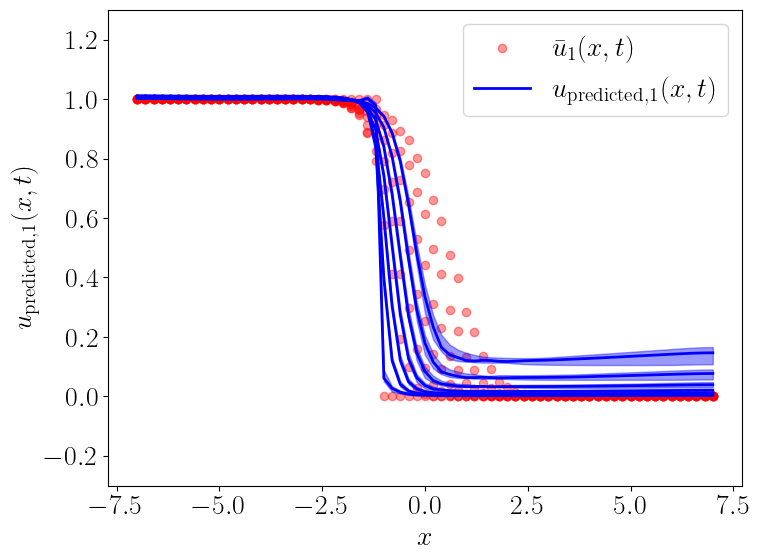

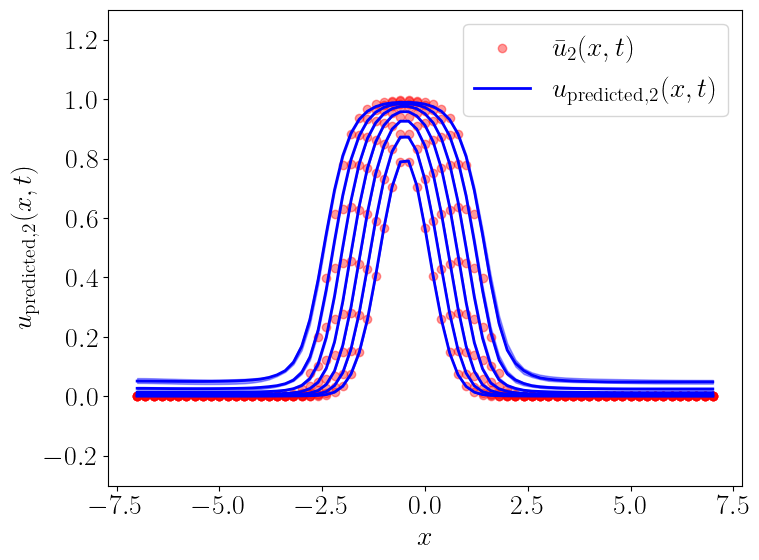

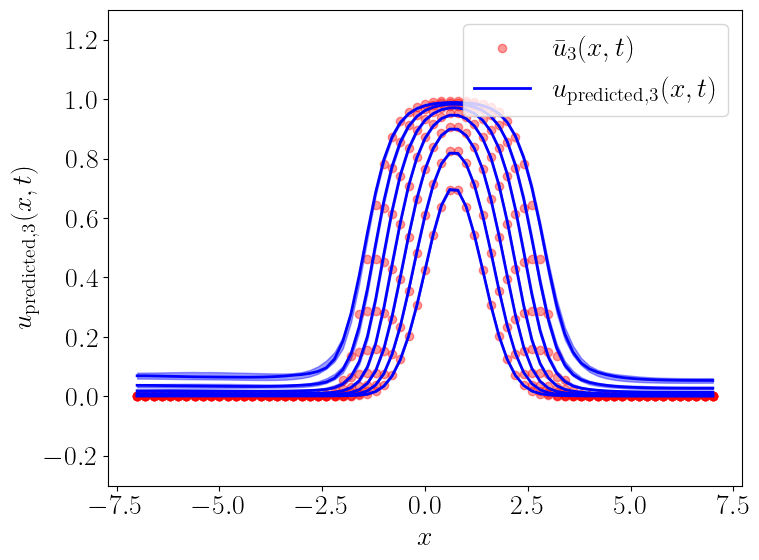

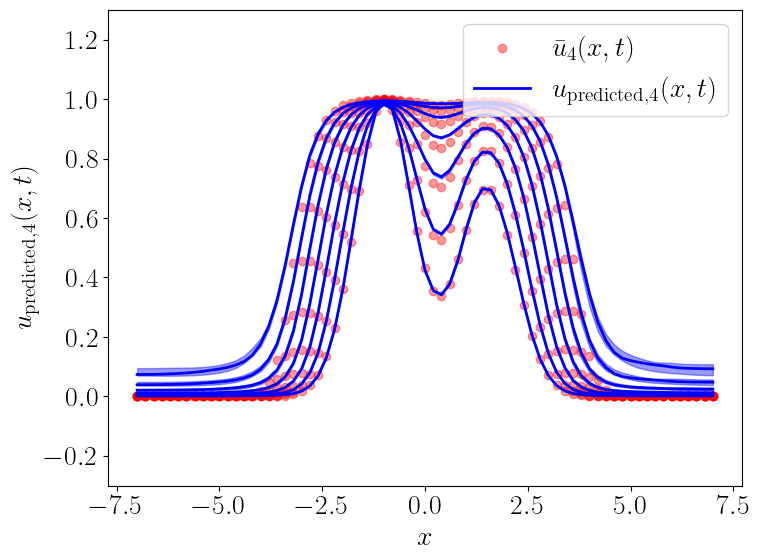

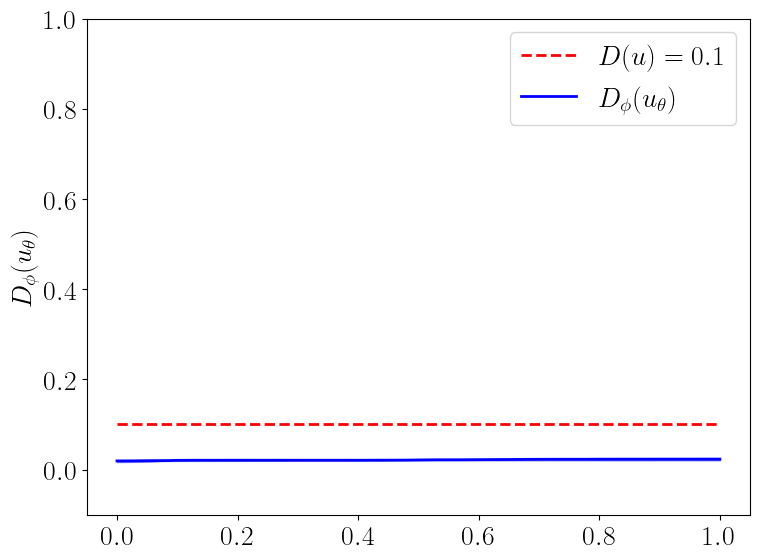

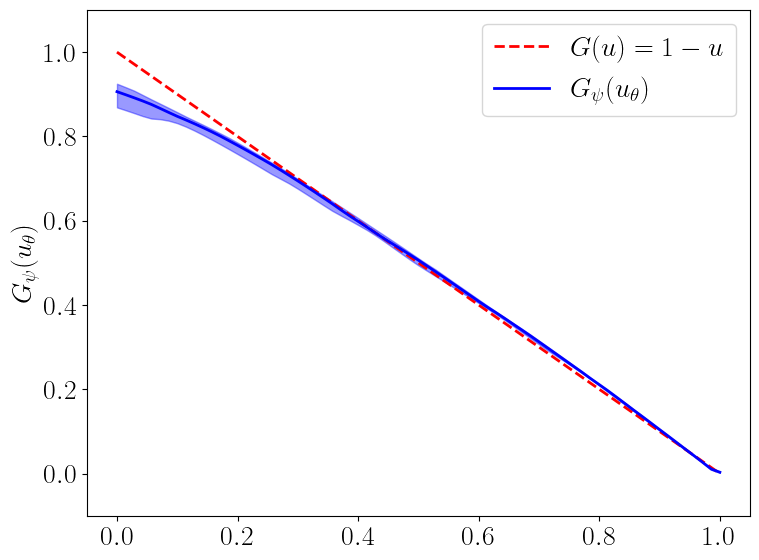

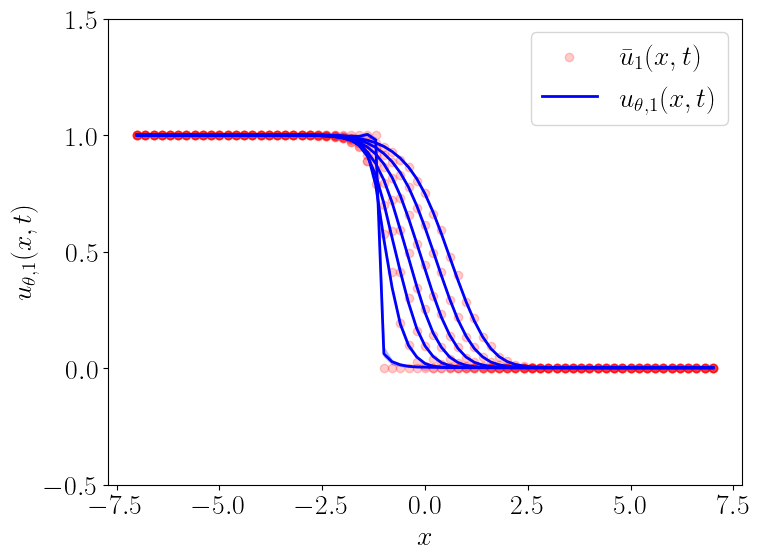

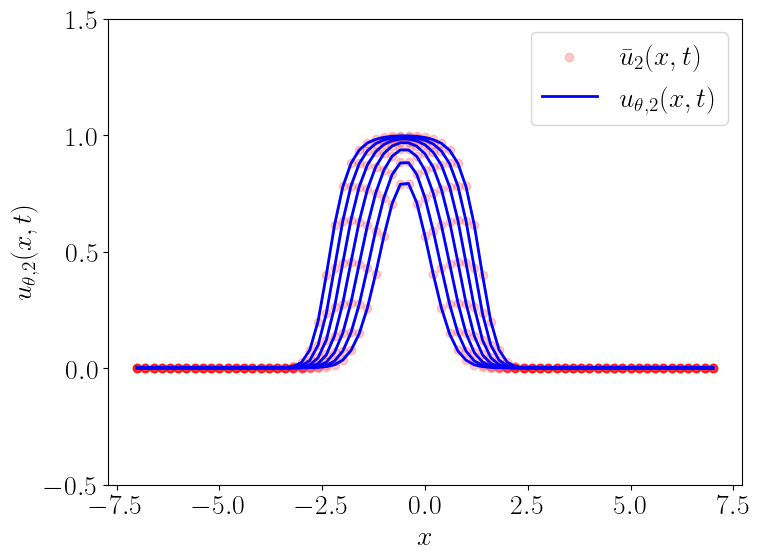

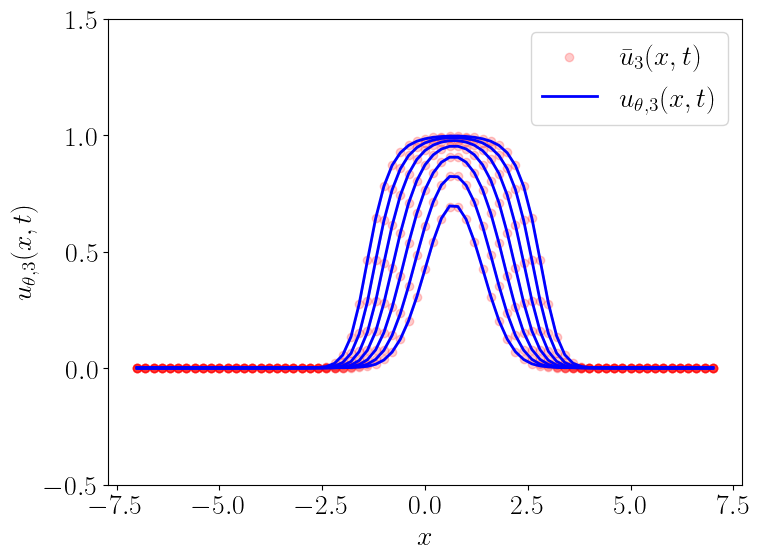

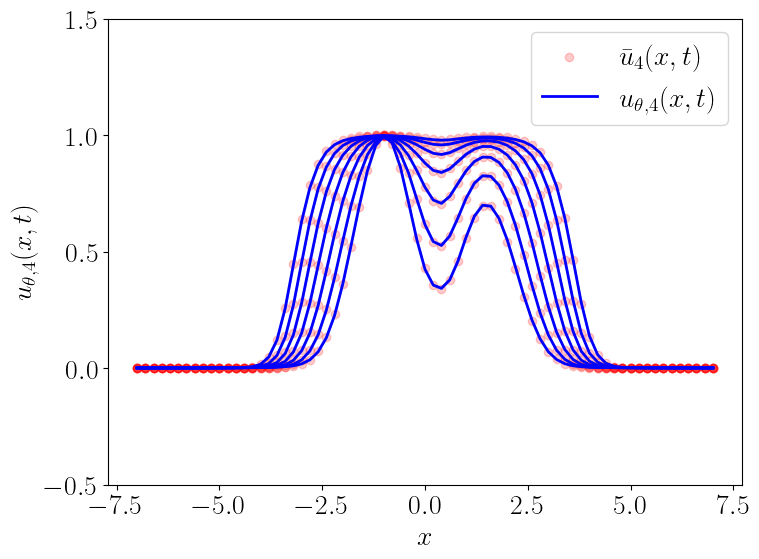

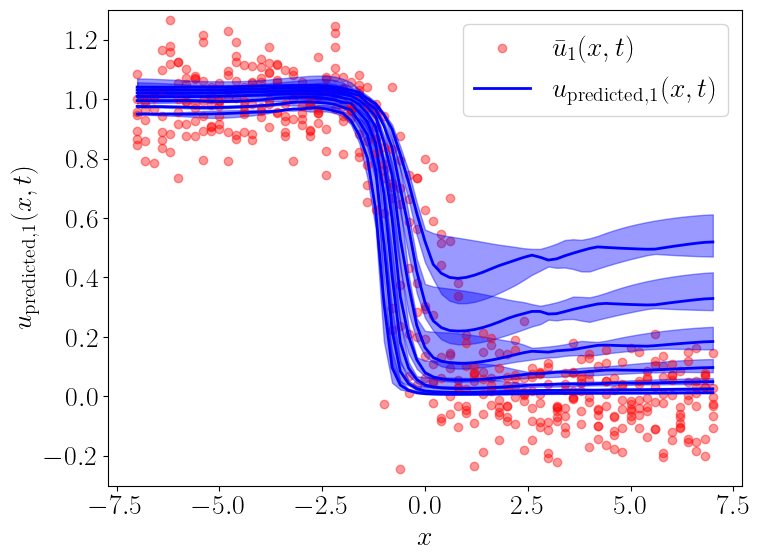

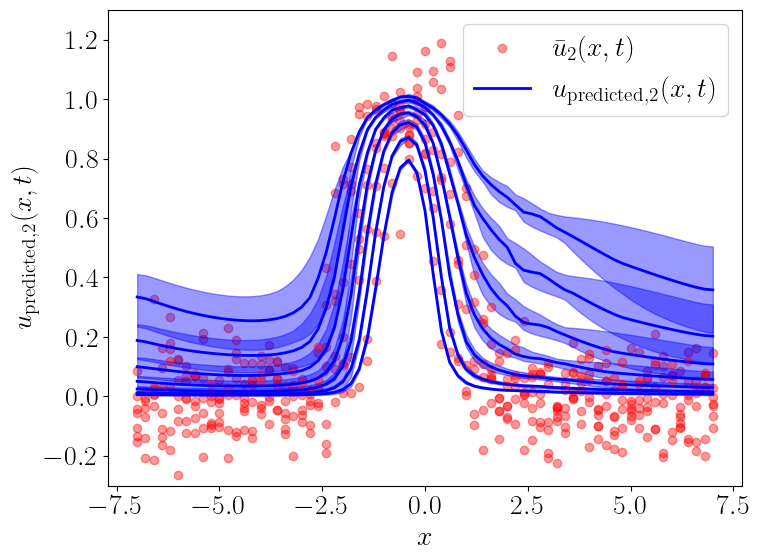

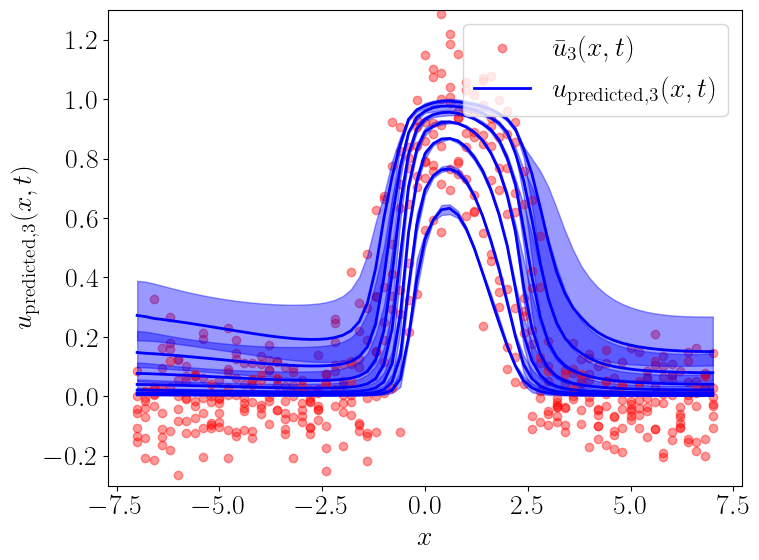

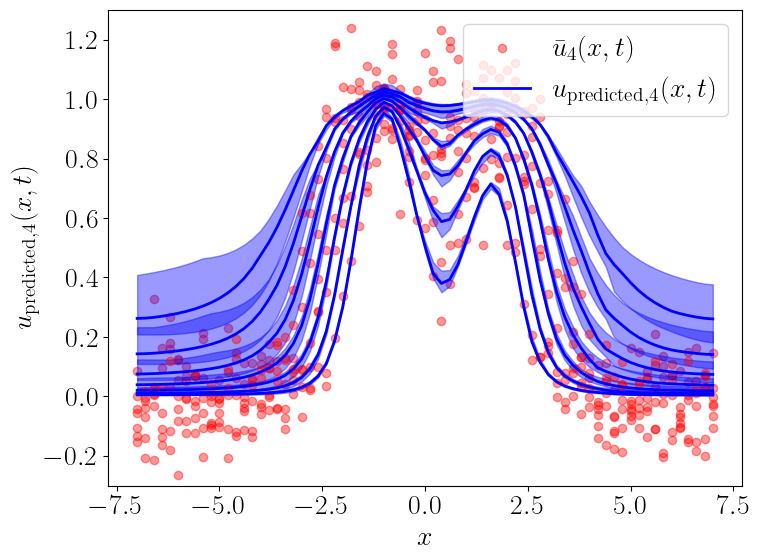

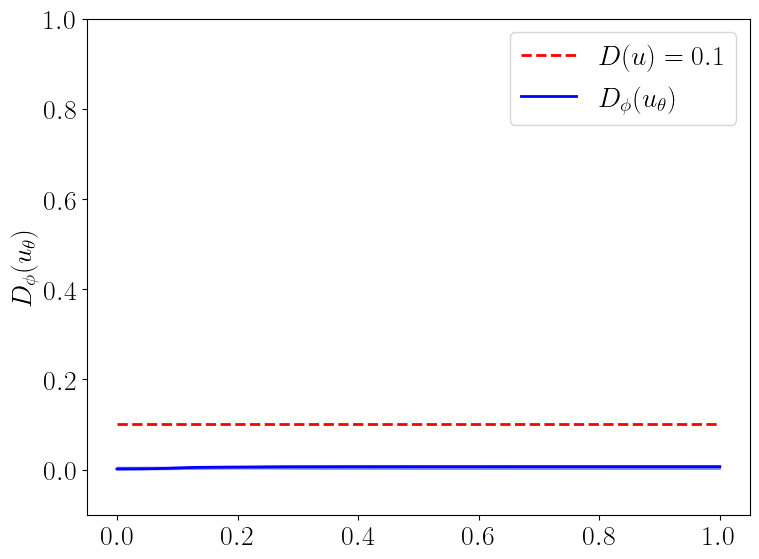

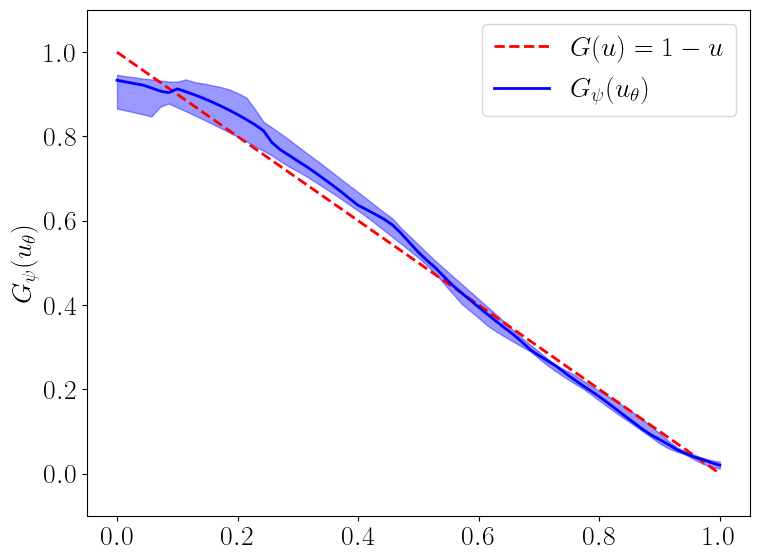

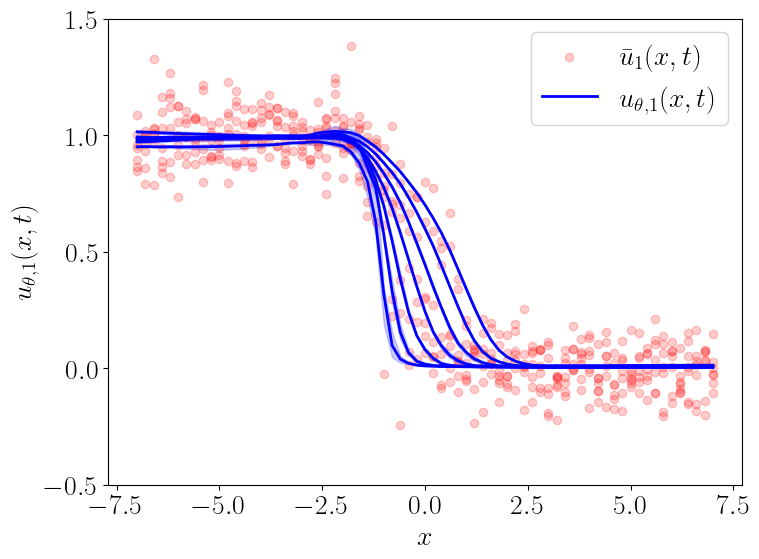

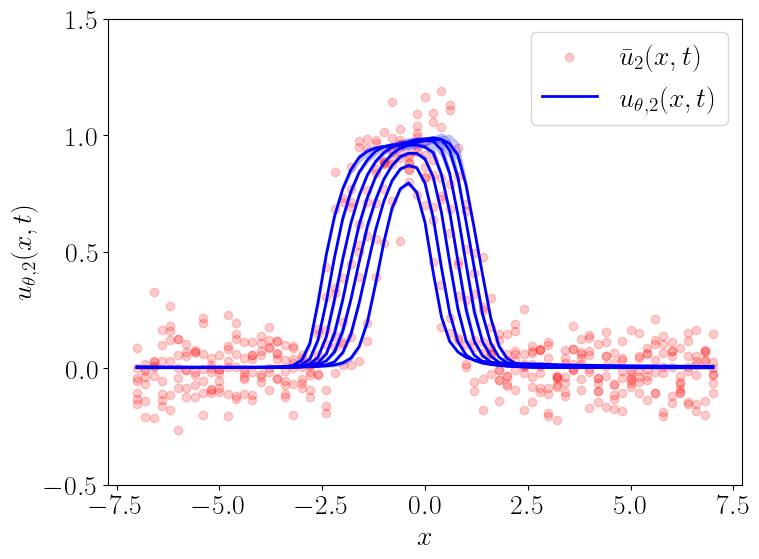

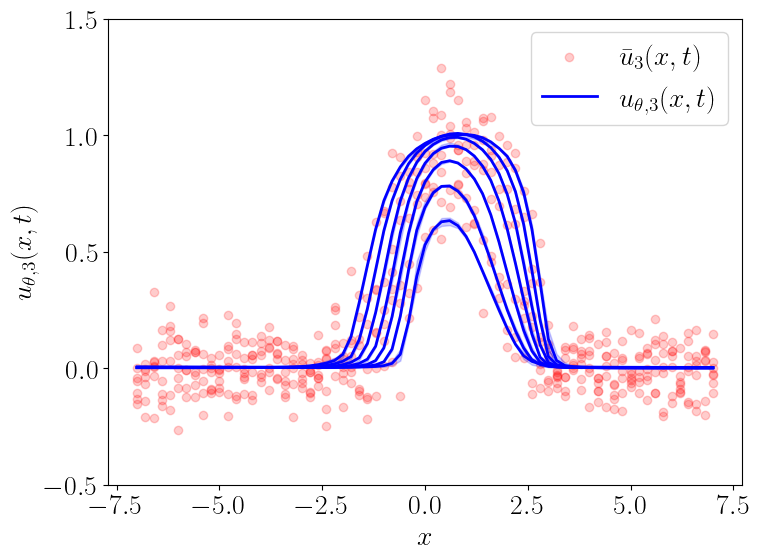

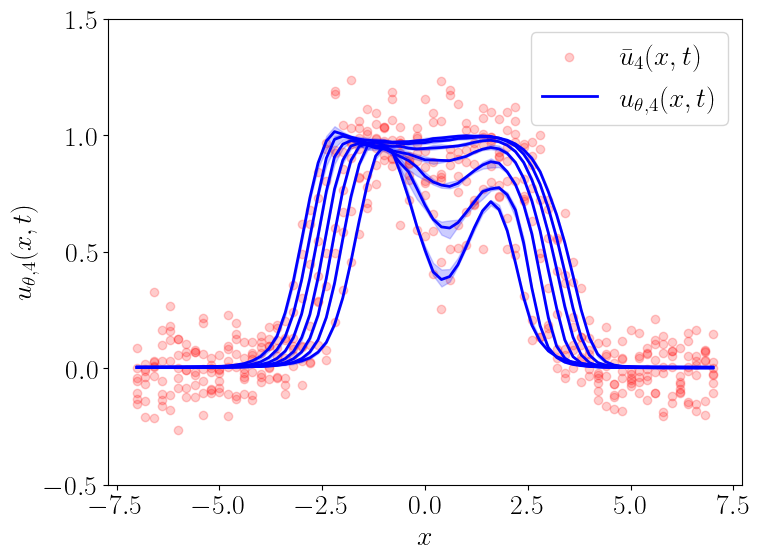

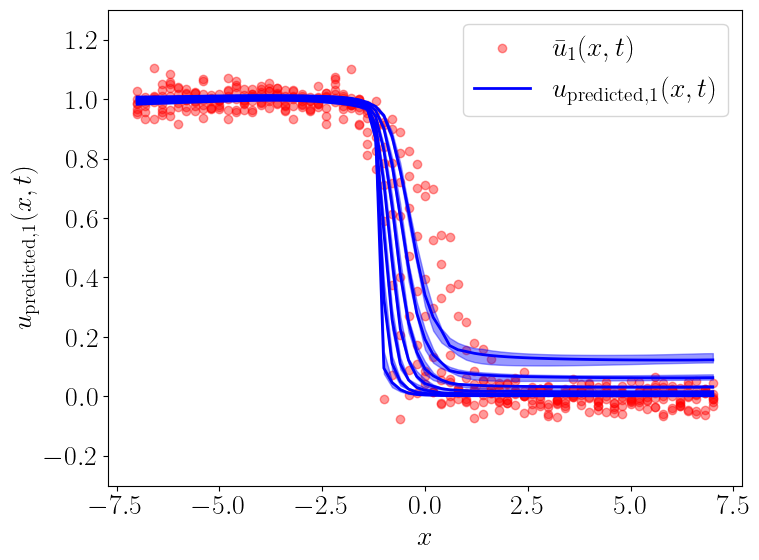

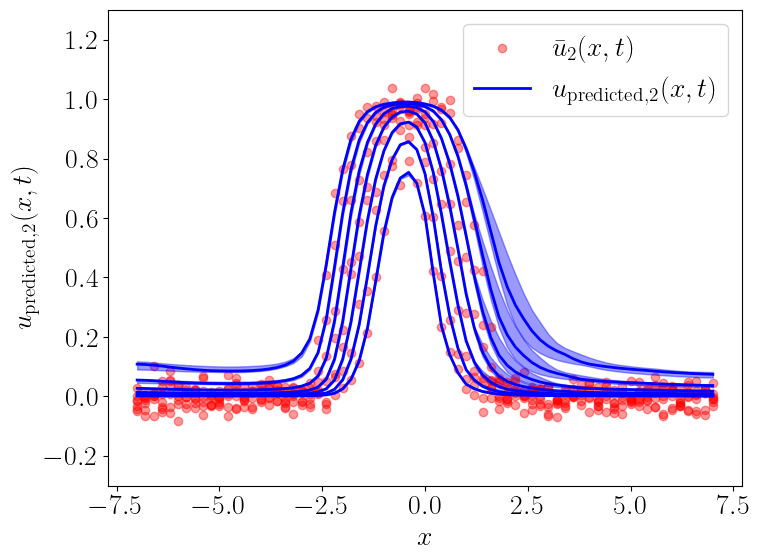

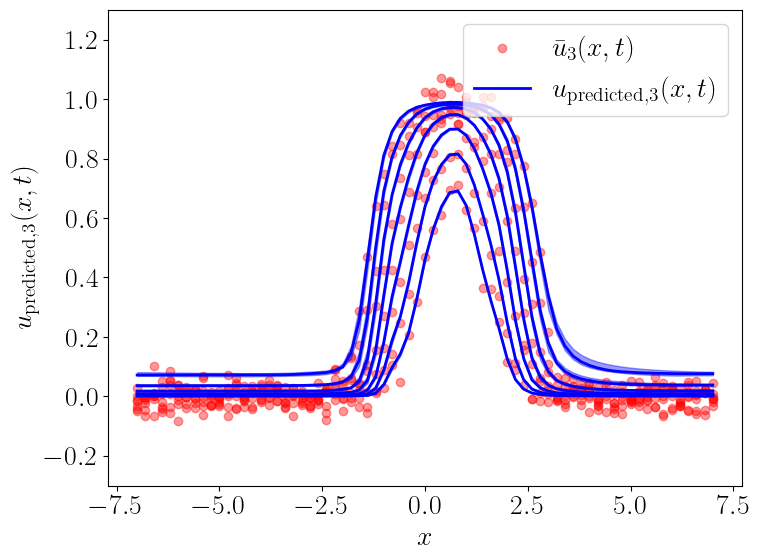

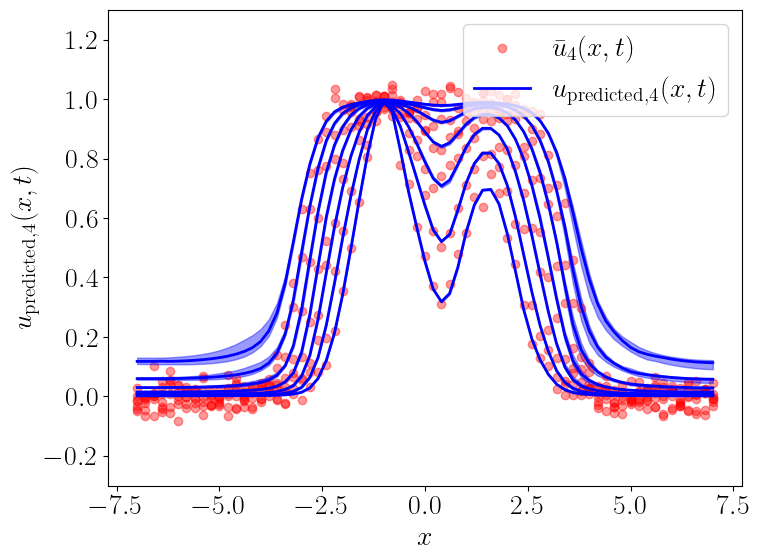

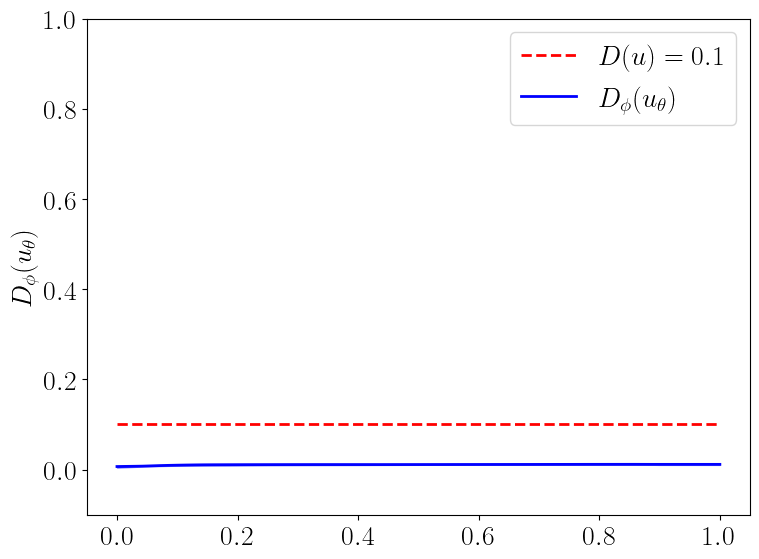

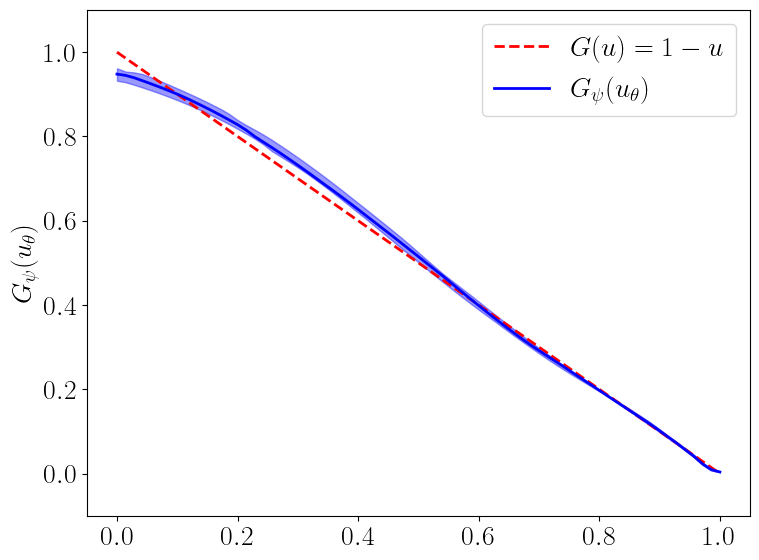

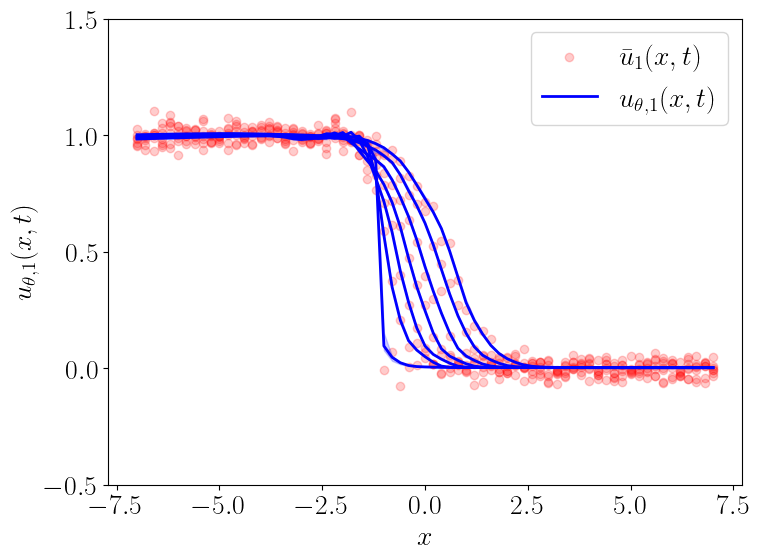

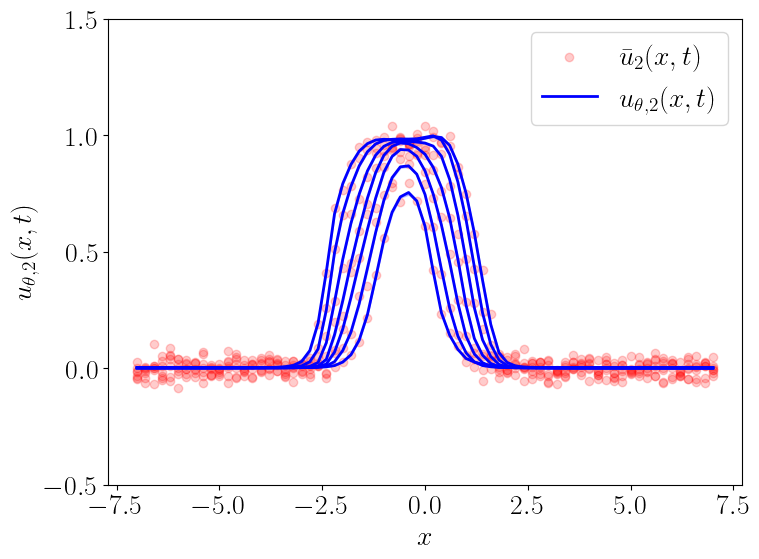

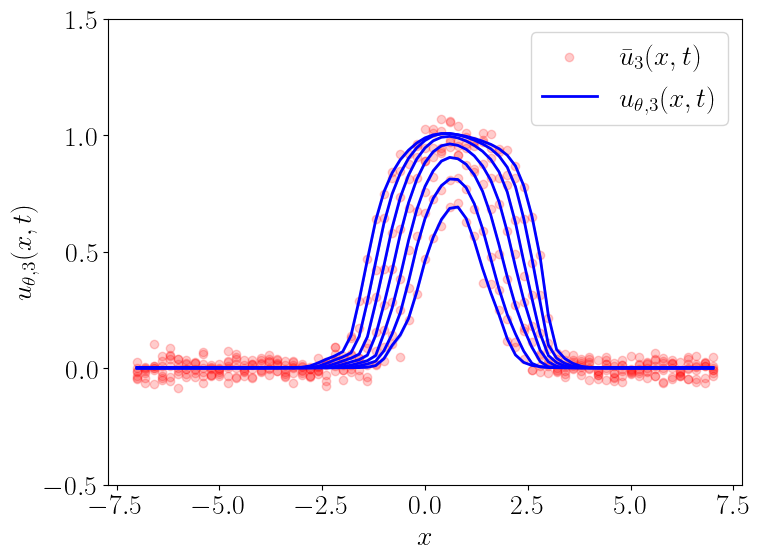

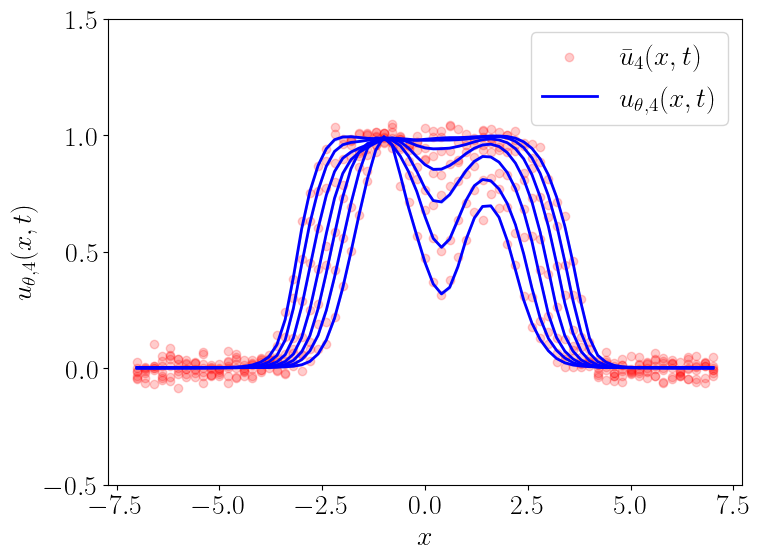

In [3]:
for var, subfolder in zip(variances, FKPPMultistart_subfolders):

    print(f"Processing variance {var}...")

    dir = top_load_folder + subfolder
    load_dir = top_load_folder + subfolder
    save_dir = top_save_folder + f'var{var}/' 
    #save_dir = top_save_folder + f'var{var}_D{D}/' #####################################
    os.makedirs(save_dir, exist_ok=True)
    

    #u_true_all = np.load(dir + f'u_allICs_var{var}_D{D}.npy') #####################################
    u_true_all = np.load(dir + f'u_allICs_var{var}.npy')
    u_true1, u_true2, u_true3, u_true4 = u_true_all[0], u_true_all[1], u_true_all[2], u_true_all[3]
    
    G_learnt = np.load(dir + f'MultiStart_var{var}/G_predS.npy')
    G_learnt_median = np.median(G_learnt, axis=0)
    G_learnt_25 = np.percentile(G_learnt, 25, axis=0)
    G_learnt_75 = np.percentile(G_learnt, 75, axis=0)

    D_learnt = np.load(dir + f'MultiStart_var{var}/D_predS.npy')
    D_learnt_median = np.median(D_learnt, axis=0)
    D_learnt_25 = np.percentile(D_learnt, 25, axis=0)
    D_learnt_75 = np.percentile(D_learnt, 75, axis=0)

    u_learnt = np.load(dir + f'MultiStart_var{var}/u_predS.npy')
    u_learn1, u_learnt2, u_learnt3, u_learnt4 = u_learnt[0], u_learnt[1], u_learnt[2], u_learnt[3]
    u_learn1_median, u_learn1_25, u_learn1_75 = np.median(u_learn1, axis=0), np.percentile(u_learn1, 25, axis=0), np.percentile(u_learn1, 75, axis=0)
    u_learn2_median, u_learn2_25, u_learn2_75 = np.median(u_learnt2, axis=0), np.percentile(u_learnt2, 25, axis=0), np.percentile(u_learnt2, 75, axis=0)
    u_learn3_median, u_learn3_25, u_learn3_75 = np.median(u_learnt3, axis=0), np.percentile(u_learnt3, 25, axis=0), np.percentile(u_learnt3, 75, axis=0)
    u_learn4_median, u_learn4_25, u_learn4_75 = np.median(u_learnt4, axis=0), np.percentile(u_learnt4, 25, axis=0), np.percentile(u_learnt4, 75, axis=0)

    # also construct the reconsrtucted u_NN at training points for each IC using the learned D and G NNs
    u_reconstr_all_1, u_reconstr_all_2, u_reconstr_all_3, u_reconstr_all_4 = [], [], [], []
    for i in range(NumRep):
        u_NN_IC_1, u_NN_IC_2, u_NN_IC_3, u_NN_IC_4 = u_learn1[i, 0, :], u_learnt2[i, 0, :], u_learnt3[i, 0, :], u_learnt4[i, 0, :]

        D_net = torch.load(load_dir + f'MultiStart_var{var}/Iter{i}/D_net_best_Iter{i}.pth', map_location=device, weights_only=False)
        G_net = torch.load(load_dir + f'MultiStart_var{var}/Iter{i}/G_net_best_Iter{i}.pth', map_location=device, weights_only=False)
        D_net.to(device); G_net.to(device)
        D_net.eval(); G_net.eval()
        
        u_pred_1 = recon_plot(x_train, t_train, D_net, G_net, u_NN_IC_1)
        u_pred_2 = recon_plot(x_train, t_train, D_net, G_net, u_NN_IC_2)
        u_pred_3 = recon_plot(x_train, t_train, D_net, G_net, u_NN_IC_3)
        u_pred_4 = recon_plot(x_train, t_train, D_net, G_net, u_NN_IC_4)
        u_reconstr_all_1.append(u_pred_1)
        u_reconstr_all_2.append(u_pred_2)
        u_reconstr_all_3.append(u_pred_3)
        u_reconstr_all_4.append(u_pred_4)
    np.save(save_dir + 'u_reconstr_all_1.npy', u_reconstr_all_1)
    np.save(save_dir + 'u_reconstr_all_2.npy', u_reconstr_all_2)
    np.save(save_dir + 'u_reconstr_all_3.npy', u_reconstr_all_3)
    np.save(save_dir + 'u_reconstr_all_4.npy', u_reconstr_all_4)


    u_reconstr_median1, u_reconstr_25_1, u_reconstr_75_1 = np.median(u_reconstr_all_1, axis=0), np.percentile(u_reconstr_all_1, 25, axis=0), np.percentile(u_reconstr_all_1, 75, axis=0)
    u_reconstr_median2, u_reconstr_25_2, u_reconstr_75_2 = np.median(u_reconstr_all_2, axis=0), np.percentile(u_reconstr_all_2, 25, axis=0), np.percentile(u_reconstr_all_2, 75, axis=0)
    u_reconstr_median3, u_reconstr_25_3, u_reconstr_75_3 = np.median(u_reconstr_all_3, axis=0), np.percentile(u_reconstr_all_3, 25, axis=0), np.percentile(u_reconstr_all_3, 75, axis=0)
    u_reconstr_median4, u_reconstr_25_4, u_reconstr_75_4 = np.median(u_reconstr_all_4, axis=0), np.percentile(u_reconstr_all_4, 25, axis=0), np.percentile(u_reconstr_all_4, 75, axis=0)

    # plot the reconstructed u_NN for all four ICs in separate single figures 
    fig11, axs11 = plt.subplots(figsize=(8, 6))
    for t in range(Nt):
        axs11.scatter(x_train, u_true1[t, :], color='red', alpha=0.4, label=r'$\bar{u}_1(x, t)$' if t == 0 else "")
        axs11.plot(x_train, u_reconstr_median1[t, :], color='blue', label=r'$u_{\mathrm{predicted}, 1}(x, t)$' if t == 0 else None)
        axs11.fill_between(x_train, u_reconstr_25_1[t, :], u_reconstr_75_1[t, :], color='blue', alpha=alpha_val)
    axs11.set_xlabel(r'$x$')
    axs11.set_ylabel(r'$u_{\mathrm{predicted}, 1}(x, t)$')
    axs11.legend(loc = 'upper right') 
    if np.min(u_reconstr_25_1.flatten()) < -3:
        pass
    else:
        axs11.set_ylim([-0.3, 1.3])
        axs11.set_yticks([-0.2, 0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2])
    fig11.tight_layout()
    fig11.savefig(save_dir + 'u_reconstr_1.svg', format='svg', bbox_inches='tight')

    fig22, axs22 = plt.subplots(figsize=(8, 6))
    for t in range(Nt):
        axs22.scatter(x_train, u_true2[t, :], color='red', alpha=0.4, label=r'$\bar{u}_2(x, t)$' if t == 0 else "")
        axs22.plot(x_train, u_reconstr_median2[t, :], color='blue', label=r'$u_{\mathrm{predicted}, 2}(x, t)$' if t == 0 else None)
        axs22.fill_between(x_train, u_reconstr_25_2[t, :], u_reconstr_75_2[t, :], color='blue', alpha=alpha_val)
    axs22.set_xlabel(r'$x$')
    axs22.set_ylabel(r'$u_{\mathrm{predicted}, 2}(x, t)$')
    axs22.legend(loc = 'upper right') 
    if np.min(u_reconstr_25_2.flatten()) < -3:
        pass
    else:
        axs22.set_ylim([-0.3, 1.3])
        axs22.set_yticks([-0.2, 0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2])
    fig22.tight_layout()
    fig22.savefig(save_dir + 'u_reconstr_2.svg', format='svg', bbox_inches='tight')

    fig33, axs33 = plt.subplots(figsize=(8, 6))
    for t in range(Nt):
        axs33.scatter(x_train, u_true3[t, :], color='red', alpha=0.4, label=r'$\bar{u}_3(x, t)$' if t == 0 else "")
        axs33.plot(x_train, u_reconstr_median3[t, :], color='blue', label=r'$u_{\mathrm{predicted}, 3}(x, t)$' if t == 0 else None)
        axs33.fill_between(x_train, u_reconstr_25_3[t, :], u_reconstr_75_3[t, :], color='blue', alpha=alpha_val)
    axs33.set_xlabel(r'$x$')
    axs33.set_ylabel(r'$u_{\mathrm{predicted}, 3}(x, t)$')
    axs33.legend(loc = 'upper right') 
    if np.min(u_reconstr_25_3.flatten()) < -3:
        pass
    else:
        axs33.set_ylim([-0.3, 1.3])
        axs33.set_yticks([-0.2, 0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2])
    fig33.tight_layout()
    fig33.savefig(save_dir + 'u_reconstr_3.svg', format='svg', bbox_inches='tight')

    fig44, axs44 = plt.subplots(figsize=(8, 6))
    for t in range(Nt):
        axs44.scatter(x_train, u_true4[t, :], color='red', alpha=0.4, label=r'$\bar{u}_4(x, t)$' if t == 0 else "")
        axs44.plot(x_train, u_reconstr_median4[t, :], color='blue', label=r'$u_{\mathrm{predicted}, 4}(x, t)$' if t == 0 else None)
        axs44.fill_between(x_train, u_reconstr_25_4[t, :], u_reconstr_75_4[t, :], color='blue', alpha=alpha_val)
    axs44.set_xlabel(r'$x$')
    axs44.set_ylabel(r'$u_{\mathrm{predicted}, 4}(x, t)$')
    axs44.legend(loc = 'upper right') 
    if np.min(u_reconstr_25_4.flatten()) < -3:
        pass
    else:
        axs44.set_ylim([-0.3, 1.3])
        axs44.set_yticks([-0.2, 0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2])
    fig44.tight_layout()
    fig44.savefig(save_dir + 'u_reconstr_4.svg', format='svg', bbox_inches='tight')


    # plot D_NN
    fig1, ax1 = plt.subplots(figsize=(8, 6))
    ax1.plot(U_grid, D_true, 'r--', label=r'$D(u)=' + f'{D:.1f}' + r'$')
    ax1.plot(U_grid, D_learnt_median, color='blue', label=r'$D_{\phi}(u_{\theta})$')
    ax1.fill_between(U_grid, D_learnt_25, D_learnt_75, color='blue', alpha=0.4)
    ax1.set_ylabel(r'$D_{\phi}(u_{\theta})$')
    ax1.legend()
    ax1.set_ylim([-0.1, 1.0])
    #ax1.set_title(f'Variance {var}')
    fig1.tight_layout()
    fig1.savefig(save_dir + 'D_NN_multiICs.svg', format='svg', bbox_inches='tight')

    # plot G_NN
    fig2, ax2 = plt.subplots(figsize=(8, 6))
    ax2.plot(U_grid, G_true, 'r--', label=r'$G(u)=1-u$')
    ax2.plot(U_grid, G_learnt_median, color='blue', label=r'$G_{\psi}(u_{\theta})$')
    ax2.fill_between(U_grid, G_learnt_25, G_learnt_75, color='blue', alpha=0.4)
    ax2.set_ylabel(r'$G_{\psi}(u_{\theta})$')
    ax2.legend()
    ax2.set_ylim([-0.1, 1.1])
    #ax2.set_title(f'Variance {var}')
    fig2.tight_layout()
    fig2.savefig(save_dir + 'G_NN_multiICs.svg', format='svg', bbox_inches='tight')

    # plot u_NN separately for each IC
    fig3, axs3 = plt.subplots(figsize=(8, 6))
    for t in range(len(u_true1)):
        axs3.scatter(x_train, u_true1[t], color='red', alpha=0.2, label=r'$\bar{u}_{1}(x, t)$' if t == 0 else "")
        axs3.plot(x_train, u_learn1_median[t, :], color='blue', label=r'$u_{\theta, 1}(x, t)$' if t == 0 else "")
        axs3.fill_between(x_train, u_learn1_25[t, :], u_learn1_75[t, :], color='blue', alpha=0.2)
    axs3.legend(loc='upper right')
    axs3.set_ylim([-0.5, 1.5])
    axs3.set_yticks([-0.5, 0.0, 0.5, 1.0, 1.5])
    axs3.set_ylabel(r'$u_{\theta, 1}(x, t)$')
    axs3.set_xlabel(r'$x$')
    #axs3.set_title(f'Variance {var}')
    fig3.tight_layout()
    fig3.savefig(save_dir + 'u_NN_multiICs_IC1.svg', format='svg', bbox_inches='tight')

    fig4, axs4 = plt.subplots(figsize=(8, 6))
    for t in range(len(u_true2)):
        axs4.scatter(x_train, u_true2[t], color='red', alpha=0.2, label=r'$\bar{u}_{2}(x, t)$' if t == 0 else "")
        axs4.plot(x_train, u_learn2_median[t, :], color='blue', label=r'$u_{\theta, 2}(x, t)$' if t == 0 else "")
        axs4.fill_between(x_train, u_learn2_25[t, :], u_learn2_75[t, :], color='blue', alpha=0.2)
    axs4.legend(loc='upper right')
    axs4.set_ylim([-0.5, 1.5])
    axs4.set_yticks([-0.5, 0.0, 0.5, 1.0, 1.5])
    axs4.set_ylabel(r'$u_{\theta, 2}(x, t)$')
    axs4.set_xlabel(r'$x$')
    #axs4.set_title(f'Variance {var}')
    fig4.tight_layout()
    fig4.savefig(save_dir + 'u_NN_multiICs_IC2.svg', format='svg', bbox_inches='tight')

    fig5, axs5 = plt.subplots(figsize=(8, 6))
    for t in range(len(u_true3)):
        axs5.scatter(x_train, u_true3[t], color='red', alpha=0.2, label=r'$\bar{u}_{3}(x, t)$' if t == 0 else "")
        axs5.plot(x_train, u_learn3_median[t, :], color='blue', label=r'$u_{\theta, 3}(x, t)$' if t == 0 else "")
        axs5.fill_between(x_train, u_learn3_25[t, :], u_learn3_75[t, :], color='blue', alpha=0.2)
    axs5.legend(loc='upper right')
    axs5.set_ylim([-0.5, 1.5])
    axs5.set_yticks([-0.5, 0.0, 0.5, 1.0, 1.5])
    axs5.set_ylabel(r'$u_{\theta, 3}(x, t)$')
    axs5.set_xlabel(r'$x$')
    #axs5.set_title(f'Variance {var}')
    fig5.tight_layout()
    fig5.savefig(save_dir + 'u_NN_multiICs_IC3.svg', format='svg', bbox_inches='tight')

    fig6, axs6 = plt.subplots(figsize=(8, 6))
    for t in range(len(u_true4)):
        axs6.scatter(x_train, u_true4[t], color='red', alpha=0.2, label=r'$\bar{u}_{4}(x, t)$' if t == 0 else "")
        axs6.plot(x_train, u_learn4_median[t, :], color='blue', label=r'$u_{\theta, 4}(x, t)$' if t == 0 else "")
        axs6.fill_between(x_train, u_learn4_25[t, :], u_learn4_75[t, :], color='blue', alpha=0.2)
    axs6.legend(loc='upper right')
    axs6.set_ylim([-0.5, 1.5])
    axs6.set_yticks([-0.5, 0.0, 0.5, 1.0, 1.5])
    axs6.set_ylabel(r'$u_{\theta, 4}(x, t)$')
    axs6.set_xlabel(r'$x$')
    #axs6.set_title(f'Variance {var}')
    fig6.tight_layout()
    fig6.savefig(save_dir + 'u_NN_multiICs_IC4.svg', format='svg', bbox_inches='tight')


Loop through variances to store u_NN and u_reconstr

In [4]:
for var, subfolder in zip(variances, FKPP_subfolders):
    noise = np.sqrt(var)

    load_dir = top_load_folder + subfolder
    save_dir = top_save_folder + f'var{var}/' 
    #save_dir = top_save_folder + f'var{var}_D{D}/' #####################################

    np.random.seed(seed)
    u_true_noisy = u_true + noise * np.random.randn(*np.shape(u_true))

    u_NN_all, D_NN_all, G_NN_all, u_reconstr_all = [], [], [], []

    for rep in range(NumRep):
        test_u_pred_np = np.load(load_dir + f'test/Iter{rep}/fullgrid_u_pred.npy')
        u_NN_all.append(test_u_pred_np)
        test_D_pred_np = np.load(load_dir + f'test/Iter{rep}/fullgrid_D_pred.npy')
        D_NN_all.append(test_D_pred_np)
        test_G_pred_np = np.load(load_dir + f'test/Iter{rep}/fullgrid_G_pred.npy')
        G_NN_all.append(test_G_pred_np)

        # load 'D_net_best_Iter0.pth' and 'G_net_best_Iter0.pth' to simulate the pde
        D_net = torch.load(load_dir + f'test/Iter{rep}/D_net_best_Iter{rep}.pth', map_location=device, weights_only=False)
        G_net = torch.load(load_dir + f'test/Iter{rep}/G_net_best_Iter{rep}.pth', map_location=device, weights_only=False)
        D_net.to(device); G_net.to(device)
        D_net.eval(); G_net.eval()

        u_NN_IC = test_u_pred_np[0, :]
        u_pred = recon_plot(x_train, t_train, D_net, G_net, u_NN_IC)
        u_reconstr_all.append(u_pred)

    u_NN_all = np.array(u_NN_all)
    D_NN_all = np.array(D_NN_all)
    G_NN_all = np.array(G_NN_all)
    u_reconstr_all = np.array(u_reconstr_all)

    np.save(save_dir + 'u_NN_all.npy', u_NN_all)
    np.save(save_dir + 'D_NN_all.npy', D_NN_all)
    np.save(save_dir + 'G_NN_all.npy', G_NN_all)
    np.save(save_dir + 'u_reconstr_all.npy', u_reconstr_all)

### Plot: FKPP u_NN, D_NN, G_NN, and u_reconstr

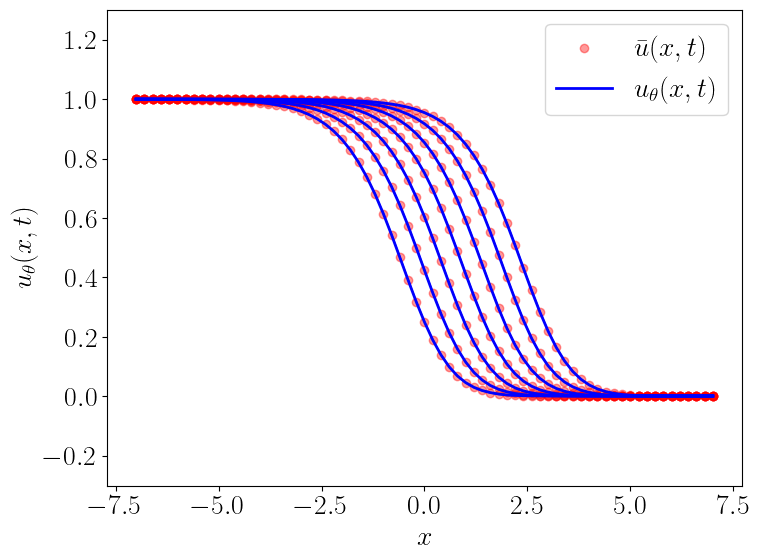

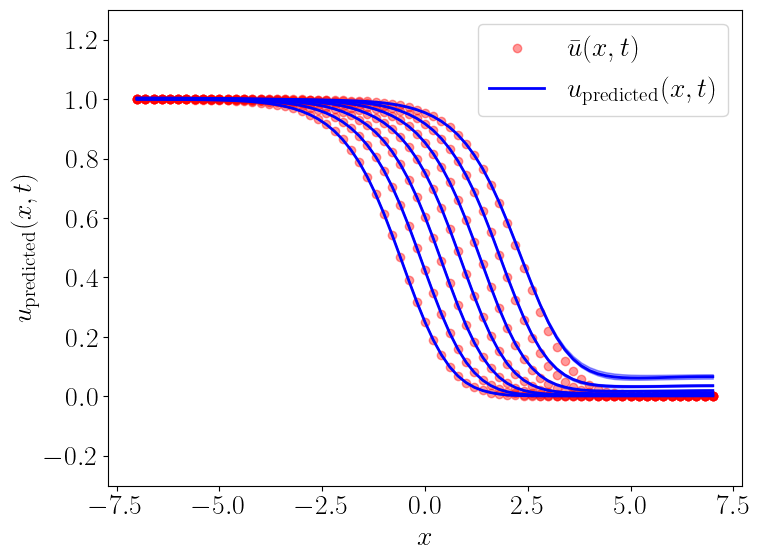

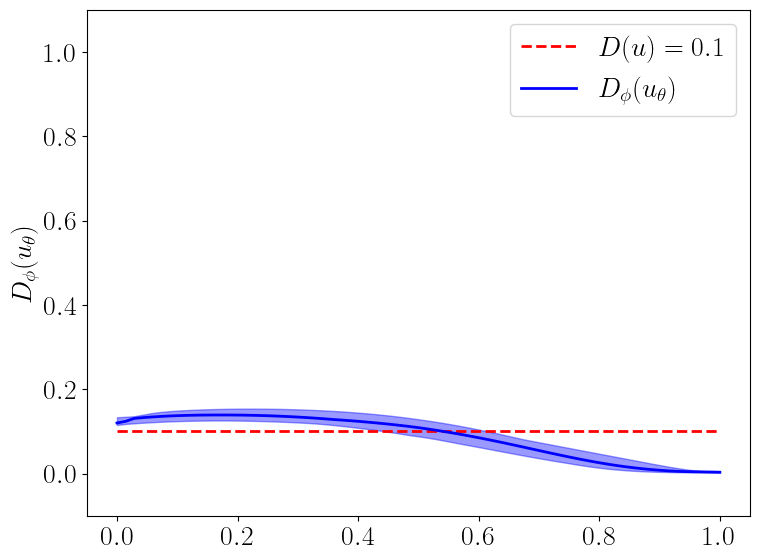

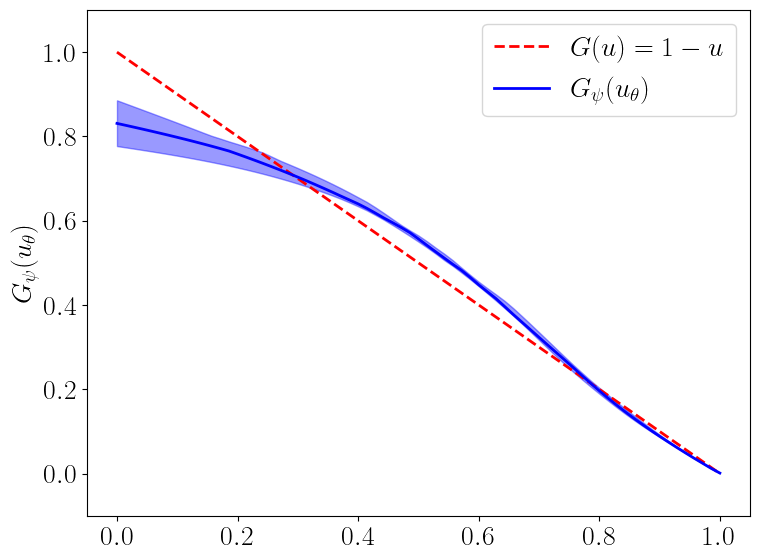

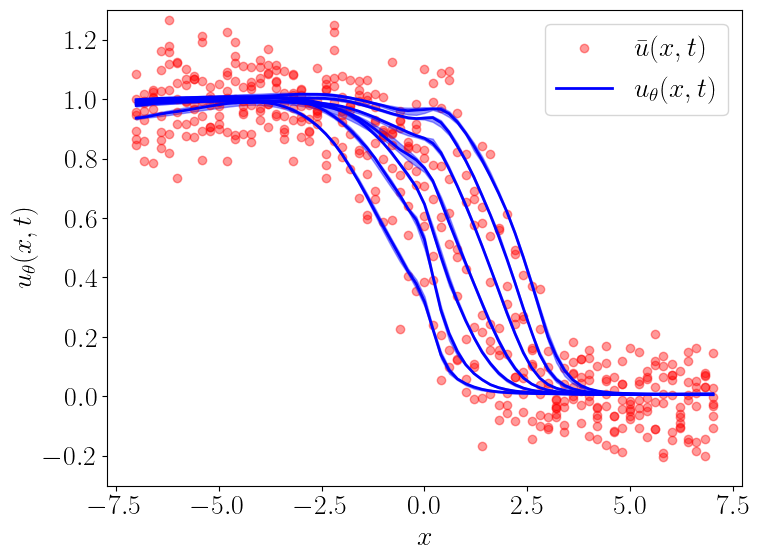

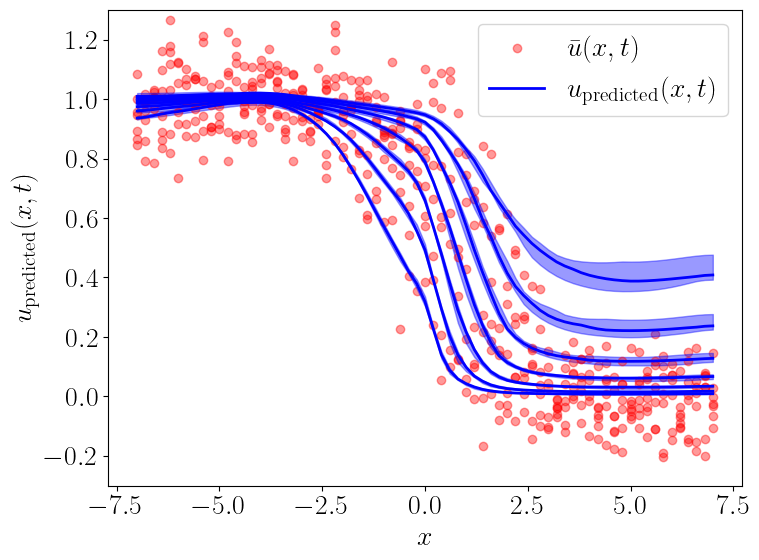

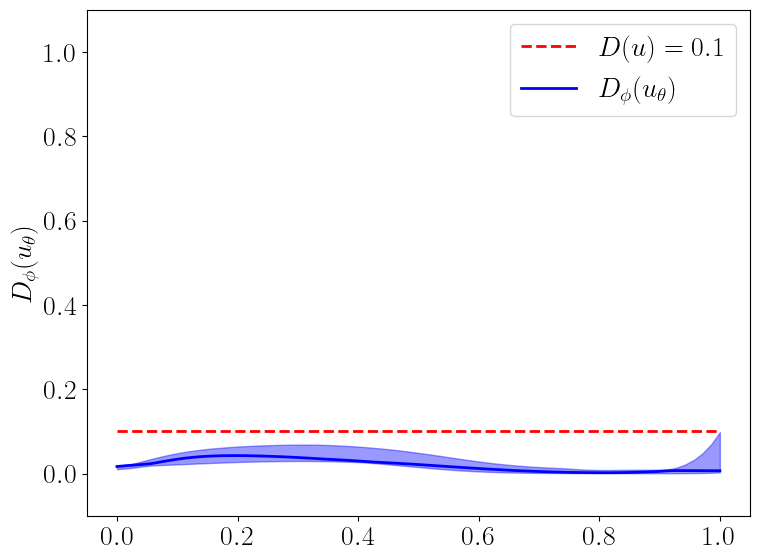

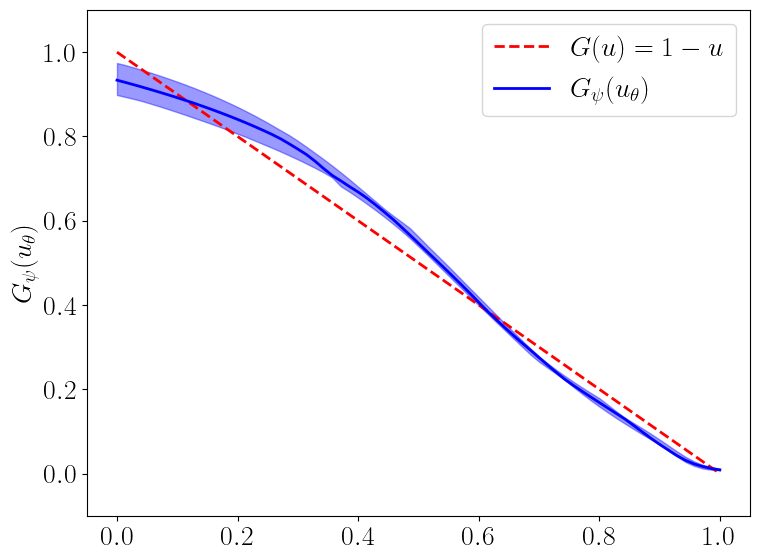

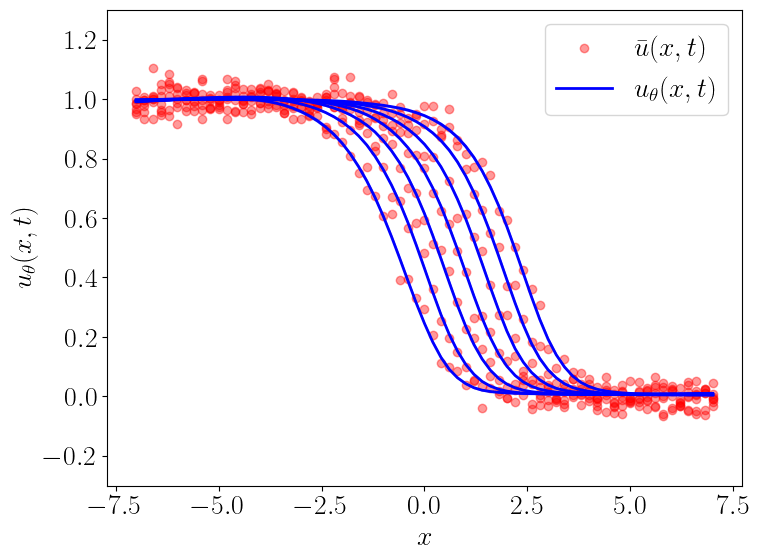

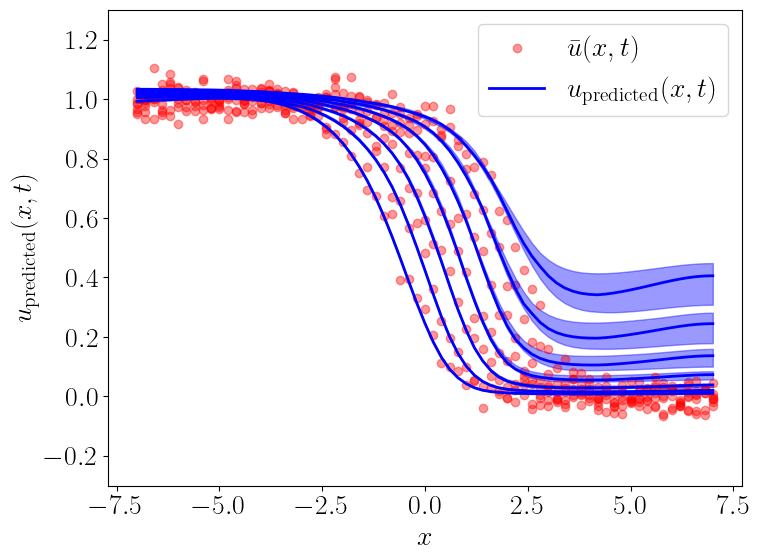

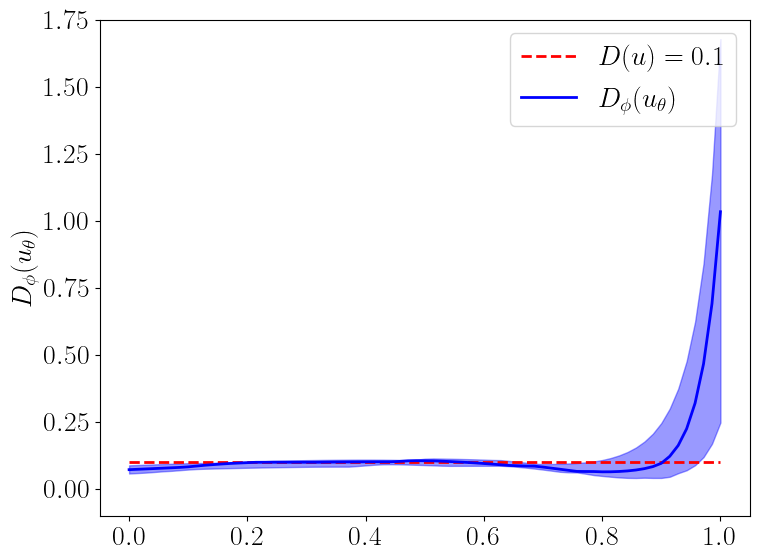

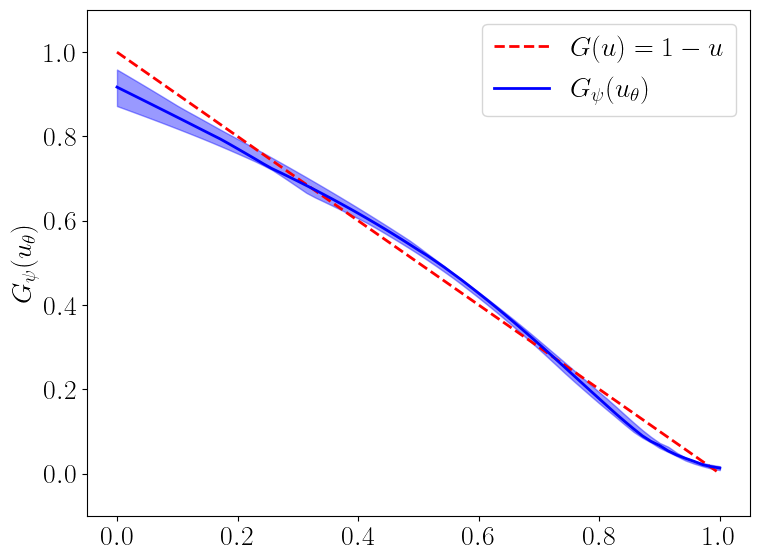

In [5]:
for var, subfolder in zip(variances, FKPP_subfolders):
    noise = np.sqrt(var)

    dir = top_save_folder + f'var{var}/' 
    #dir = top_save_folder + f'var{var}_D{D}/' #####################################

    np.random.seed(seed)
    u_true_noisy = u_true + noise * np.random.randn(*np.shape(u_true))

    u_NN_all = np.load(dir + 'u_NN_all.npy')
    D_NN_all = np.load(dir + 'D_NN_all.npy')
    G_NN_all = np.load(dir + 'G_NN_all.npy')
    u_reconstr_all = np.load(dir + 'u_reconstr_all.npy')

    u_reconstr_all_median = np.array(u_reconstr_all) # shape (NumRep, Nt, Nx)
    u_NN_all = np.array(u_NN_all) 
    D_NN_all = np.array(D_NN_all) 
    G_NN_all = np.array(G_NN_all)

    u_reconstr_median = np.median(u_reconstr_all, axis=0)
    u_reconstr_25 = np.percentile(u_reconstr_all, 25, axis=0)
    u_reconstr_75 = np.percentile(u_reconstr_all, 75, axis=0)
    u_NN_median = np.median(u_NN_all, axis=0)
    u_NN_25 = np.percentile(u_NN_all, 25, axis=0)
    u_NN_75 = np.percentile(u_NN_all, 75, axis=0)
    d_NN_median = np.median(D_NN_all, axis=0)
    d_NN_25 = np.percentile(D_NN_all, 25, axis=0)
    d_NN_75 = np.percentile(D_NN_all, 75, axis=0)
    g_NN_median = np.median(G_NN_all, axis=0)
    g_NN_25 = np.percentile(G_NN_all, 25, axis=0)
    g_NN_75 = np.percentile(G_NN_all, 75, axis=0)

    # plot u_NN vs true solution at training points
    fig1, ax1 = plt.subplots(figsize=(8, 6))
    for t in range(Nt):
        ax1.scatter(x_train, u_true_noisy[t, :], color='red', alpha=0.4, label=r'$\bar{u}(x, t)$' if t == 0 else "")
        ax1.plot(x_train, u_NN_median[t, :], color='blue', label=r'$u_{\theta}(x, t)$' if t == 0 else None)
        ax1.fill_between(x_train, u_NN_25[t, :], u_NN_75[t, :], color='blue', alpha=alpha_val)
    ax1.set_xlabel(r'$x$')
    ax1.set_ylabel(r'$u_{\theta}(x, t)$')
    ax1.legend(loc = 'upper right') 
    ax1.set_ylim([-0.3, 1.3])
    ax1.set_yticks([-0.2, 0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2])
    fig1.tight_layout()
    fig1.savefig(dir + 'u_NN.svg', format='svg', bbox_inches='tight')

    # plot u_reconstr vs true solution at training points
    fig2, ax2 = plt.subplots(figsize=(8, 6))
    for t in range(Nt):
        ax2.scatter(x_train, u_true_noisy[t, :], color='red', alpha=0.4, label=r'$\bar{u}(x, t)$' if t == 0 else "")
        ax2.plot(x_train, u_reconstr_median[t, :], color='blue', label=r'$u_{\mathrm{predicted}}(x, t)$' if t == 0 else None)
        ax2.fill_between(x_train, u_reconstr_25[t, :], u_reconstr_75[t, :], color='blue', alpha=alpha_val)
    ax2.set_xlabel(r'$x$')
    ax2.set_ylabel(r'$u_{\mathrm{predicted}}(x, t)$')
    ax2.legend(loc = 'upper right') 
    if np.min(u_reconstr_25.flatten()) < -3:
        pass
    else:
        ax2.set_ylim([-0.3, 1.3])
        ax2.set_yticks([-0.2, 0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2])
    fig2.tight_layout()
    fig2.savefig(dir + 'u_reconstr.svg', format='svg', bbox_inches='tight')

    # plot D_NN
    fig3, ax3 = plt.subplots(figsize=(8, 6))
    ax3.plot(U_grid, D_true, 'r--', label=r'$D(u)=' + f'{D:.1f}' + r'$')
    ax3.plot(U_grid, d_NN_median, color='blue', label=r'$D_{\phi}(u_{\theta})$')
    ax3.fill_between(U_grid, d_NN_25, d_NN_75, color='blue', alpha=alpha_val)
    ax3.set_ylabel(r'$D_{\phi}(u_{\theta})$')
    ax3.legend(loc = 'upper right')
    #####################################
    if np.max(d_NN_75) > 1.5:
        ax3.set_ylim([-0.1, 1.75])
    else:
        ax3.set_ylim([-0.1, 1.1])
        ax3.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    fig3.tight_layout()
    fig3.savefig(dir + 'D_NN.svg', format='svg', bbox_inches='tight')

    # plot G_NN
    fig4, ax4 = plt.subplots(figsize=(8, 6))
    ax4.plot(U_grid, G_true, 'r--', label=r'$G(u)=1-u$')
    ax4.plot(U_grid, g_NN_median, color='blue', label=r'$G_{\psi}(u_{\theta})$')
    ax4.fill_between(U_grid, g_NN_25, g_NN_75, color='blue', alpha=alpha_val)
    ax4.set_ylabel(r'$G_{\psi}(u_{\theta})$')
    ax4.set_ylim([-0.1, 1.1])
    ax4.legend(loc = 'upper right')
    ax4.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    fig4.tight_layout()
    fig4.savefig(dir + 'G_NN.svg', format='svg', bbox_inches='tight')

